# Homework 2
### PSTAT 131/231

## Linear Regression and KNN
For this assignment, we will be working with a dataset from the UCI (University of California, Irvine) Machine Learning repository ([see website here](https://archive.ics.uci.edu/dataset/1/abalone)). The full dataset consists of 4,177 observations of abalone in Tasmania. (Fun fact: Tasmania supplies about 25\% of the yearly world abalone harvest.)


The age of an abalone is typically determined by cutting the shell open and counting the number of rings with a microscope. The purpose of this data set is to determine whether abalone age <b>(number of rings + 1.5)</b> can be accurately predicted using other, easier-to-obtain information about the abalone.

The full abalone data set is located in the \data subdirectory. Before moving on import the necessary libraries and load the data in using read_csv() like in homework #1. Take a moment to read through the codebook (abalone_codebook.txt) and familiarize yourself with the variable definitions.

### Scikit-Learn
We will be using Scikit-learn, sometimes reffered to as sklearn, to work with models like linear regression and k-nearest neighbors in python. Scikit-learn is a robust machine learning library that features various classification, regression and clustering algorithms. If you successfully followed the instructions for setting up the proper virtual environment, no further installation is necessary.

Due to the size of Scikit-learn, when importing the library we import specific modules or functions. Since this is the first assignment using Scikit-learn, the importing is already handeled below. Once you've gotten a look at how Scikit-learn imports are handled, import pandas, numpy, matplotlib.pyplot and seaborn with the usual alias'.

In [8]:
# Here we import the classes and functions we'll use in this assignment from sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# Import numpy, pandas, matplotlib.pyplot and seaborn with the usual alias'. Then read in the data. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed
np.random.seed(42)

abalone_data = pd.read_csv("data/abalone.csv")
abalone_data.head(2)

,type,longest_shell,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.15,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.07,7


## Setting Up Data

### Question 1
Your goal is to predict abalone age, which is calculated as the number of rings plus 1.5. Notice there currently is no age variable in the data set. Add an age column to the dataframe `abalone_data` then describe the distribution of age. To describe the distribution you can use a seaborn histogram, boxplot or some summary statistics.

* Adding new columns to a dataframe is relatively easy, here are some [examples](https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html) in the pandas documentation. 

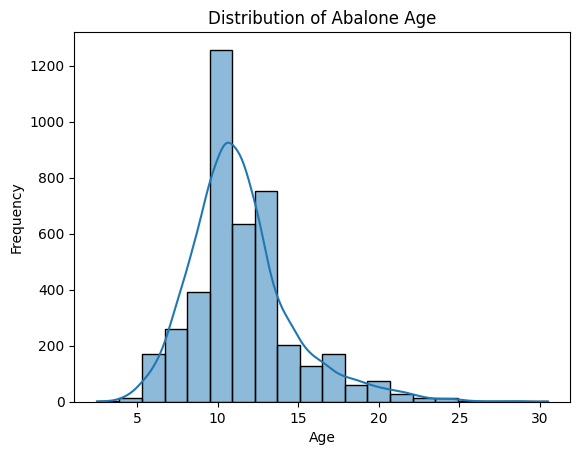

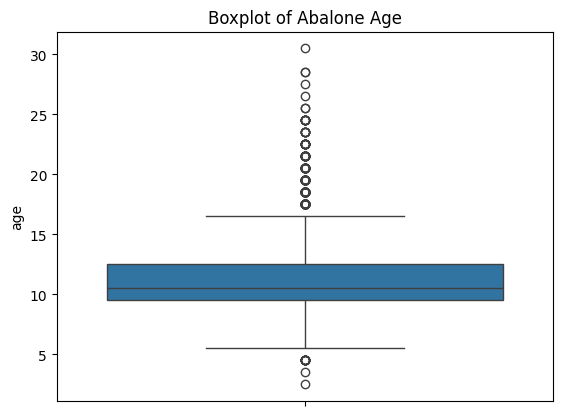

In [9]:
# Create a new column called 'age' in abalone data
abalone_data['age'] = abalone_data['rings'] + 1.5

# Once the column has been created describe the distribution
abalone_data['age'].describe()

#histogram
sns.histplot(abalone_data['age'], bins=20, kde=True)
plt.title("Distribution of Abalone Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#boxplot 
sns.boxplot(abalone_data['age'])
plt.title("Boxplot of Abalone Age")
plt.show()

### Question 2 
Split the abalone data into training and testing splits with stratified sampling. You should decide on appropriate percentages for splitting the data. In sklearn this can be done with [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) which we imported above. Stratified sampling in sklearn requires us to filter out any elements of the stratified variable that occur once. As removing variables that only occur once isn't entirely intuitive the code to remove any necessary elements can be found in the below chunk. Pay special attention to what it is doing and then create training and testing splits with [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [10]:
# Here we remove any elements in age that only occur once.
abalone_age_counts = abalone_data['age'].value_counts() # Get the counts of our variables in the age column
abalone_data = abalone_data[abalone_data['age'].isin(abalone_age_counts[abalone_age_counts > 1].index)] # Use the counts as a mask to only take ages that appear more than once.

In [11]:
abalone_train, abalone_test = train_test_split(
    abalone_data,
    test_size=0.2,
    random_state=42,
    stratify=abalone_data['age']
)

## Setting Up Model Objects

In Scikit-learn in order to use models like k-nearest neighbors and linear regression, we initialize several different objects which are imported above. 

These objects have different methods, ones we use later are shown below:

* [.fit()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) fits the model with our training data.
* [.predict()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) allows us to put in new data and get predictions.

### Question 3
Create a linear regression model object using the class we imported earlier.

In [12]:
# Create the linear_model with an sklearn import.
linear_model = LinearRegression()

### Question 4
Create a KNN model object using the class we imported earlier. Specify n_neighbors = 7.

In [13]:
# Create the knn_model with an sklearn import.
knn_model = KNeighborsRegressor(n_neighbors=7)

## Preparing Our Data
Similarly to R, we'll need to transform our data prior to using machine learning models like linear regression. This process varies from task to task but for this assignment we will be dummy coding categorical variables and centering and scaling our data. Unlike in R with Tidyverse, the option to create a recipe in python is not straightforward. While this does mean slightly more work, it also means we have more control over what is happening step by step.


### Question 5 
Create a function to pre-process the data prior to modelling. Take note that the data going into this function will not include rings and age. Below your function, explain why you shouldn't use rings to predict age. 

To center and scale our variables in Scikit-learn we will be using [StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler). Like linear regression and k-nearest neighbors model objects, standard scalar has its state modified once fitted with data. Because of this, the object must be saved after fitting training data in order to re-use it on separate examples or testing data. To handle this, initialize the standard scalar object outside of the function and use booleans to determine if you fit data to the scalar or not.

What your pre-process function should do in order:
* Dummy code any categorical predictors with [pd.get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), utilize the dtype parameter so that your dummy coded predictors are numerical. 

* Create interactions between
    * `type` and `shucked_weight`
    * `longest_shell` and `diameter`
    * `shucked_weight` and `shell_weight`

* Center and scale all predictors with [StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

**Hint**: When creating interaction terms that categorical variables get dummy coded into several columns, for these predictors you may want to use a for loop or write out individual cases. 



In [14]:
# Import and initialize StandardScalar from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

def preprocess(abalone_data : pd.DataFrame, is_training : bool) -> pd.DataFrame:
    """
    Takes in abalone data and prepares it for usage in k-nearest neighbors and linear regression models
    by dummy coding variables, creating interaction terms and centering and scaling all predictors.

    Args:
        abalone_data (pd.DataFrame) : The pandas dataframe containing the abalone dataset.
        is_training (bool) :  A boolean that signifies if the scalar needs to be fit or not.
    Returns:
        abalone_processed (pd.DataFrame) : The processed abalone dataset, ready for modelling.
    """

    # We make a copy of the abalone_predictors dataframe to avoid modifying the original dataframe
    abalone_processed = abalone_data.copy()
    
    # Standard_scalar returns a numpy array, which we combine with column names to make a dataframe again.
    column_names = abalone_processed.columns

    # Preprocess data
    abalone_processed = pd.get_dummies(abalone_processed, dtype=float)

    #type * shucked_weight
    for col in abalone_processed.columns:
        if col.startswith("type_"):
            abalone_processed[f"{col}_shucked_weight"] = abalone_processed[col] * abalone_processed["shucked_weight"]


    #longest_shell * diameter  
    abalone_processed["longest_shell_diameter"] = abalone_processed["longest_shell"] * abalone_processed["diameter"]

    #shucked_weight * shell_weight
    abalone_processed["shucked_shell_weight"] = abalone_processed["shucked_weight"] * abalone_processed["shell_weight"]
     
    column_names = abalone_processed.columns

    # Scale and center predictors.
    abalone_processed = scaler.fit_transform(abalone_processed) if is_training else scaler.transform(abalone_processed)
    

    # We return a Dataframe 
    return pd.DataFrame(abalone_processed, columns = column_names)

**Why shouldn't rings be included?**

Rings should not be included because they are directly related to age, which is the exact thing we are trying to determind. If they are included this would mean we are unable to learn anything about the predictors. When trying to learn about the predictors the model cannot have the answer. 

## Fitting Models

### Question 6
Now, for each of these models (linear regression and KNN):

1. Store the age column of the dataset in a separate variable called `abalone_train_outcome`.
2. Drop the age and rings column using [.drop()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html).
1. Apply the preprocessing function you created earlier to the training dataset.
3. Fit the model using the models [.fit()]() method

In [15]:
# Store the age column.
abalone_train_outcome = abalone_data["age"]

# Preprocess the data.
abalone_train_new = abalone_data.drop(columns = ["age","rings"])
abalone_train_new.head(2)

abalone_train_new = preprocess(abalone_train_new, is_training=True)


In [16]:
# Fit the linear and knn models, setting the X and y parameters accordingly.
linear_model.fit(abalone_train_new, abalone_train_outcome)
knn_model.fit(abalone_train_new, abalone_train_outcome)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Question 6
Use your linear_model object to predict the age of 3 abalone as described below. Remember that you need to preprocess data, the data needs to be in the form of a dataframe and your preprocess function assumes you do not have rings and age columns.

The 3 abalone we will predict:
* a hypothetical female abalone with longest_shell = 0.50, diameter = 0.10, height = 0.30, whole_weight = 4, shucked_weight = 1, viscera_weight = 2, and shell_weight = 1.
* a hypothetical male abalone with longest_shell = 0.70, diameter = 0.15, height = 0.34, whole_weight = 6, shucked_weight = 2, viscera_weight = 3, and shell_weight = 1.
* a hypothetical infant abalone with longest_shell = 0.25, diameter = 0.5, height = 0.20, whole_weight = 3, shucked_weight = 0.5, viscera_weight = 1, and shell_weight = 0.5.


In [17]:
abalone_examples = pd.DataFrame({
    "type": ["F", "M", "I"],
    "longest_shell": [0.50, 0.70, 0.25],
    "diameter": [0.10, 0.15, 0.50],
    "height": [0.30, 0.34, 0.20],
    "whole_weight": [4, 6, 3],
    "shucked_weight": [1, 2, 0.5],
    "viscera_weight": [2, 3, 1],
    "shell_weight": [1, 1, 0.5]
})

abalone_examples_processed = preprocess(abalone_examples, is_training=False)

predictions = linear_model.predict(abalone_examples_processed)

print(predictions)

[24.56631692 19.24927259 31.58180122]


## Assessing Performance
Now we want to assess our models performance, luckily for us Scikit-learn has some functions we can use for that!

### Question 7
Figure out how to import the following functions from [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics): $R^2$, RMSE (root mean squared error) and MAE (mean absolute error). Then get predictions from both linear and knn models and place them in the imported functions along with the testing data. Report the results and then interpret the $R^2$ value.

In [18]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

abalone_test_outcome = abalone_test["age"]

abalone_test_new = abalone_test.drop(columns=["age", "rings"])
abalone_test_new = preprocess(abalone_test_new, is_training=False)

linear_pred = linear_model.predict(abalone_test_new)
knn_pred = knn_model.predict(abalone_test_new)

linear_r2 = r2_score(abalone_test_outcome, linear_pred)
linear_rmse = root_mean_squared_error(abalone_test_outcome, linear_pred)
linear_mae = mean_absolute_error(abalone_test_outcome, linear_pred)

knn_r2 = r2_score(abalone_test_outcome, knn_pred)
knn_rmse = root_mean_squared_error(abalone_test_outcome, knn_pred)
knn_mae = mean_absolute_error(abalone_test_outcome, knn_pred)

# Print results
print("Linear Regression:")
print("R^2:", linear_r2)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)

print("\nKNN:")
print("R^2:", knn_r2)
print("RMSE:", knn_rmse)
print("MAE:", knn_mae)

Linear Regression:
R^2: 0.5363349408422456
RMSE: 2.1398707893903737
MAE: 1.532882293931181

KNN:
R^2: 0.6174074241039169
RMSE: 1.9438092066723713
MAE: 1.3787852865697177


## Required for 231 Students
In lecture, we presented the general bias-variance tradeoff, which takes the form:
$$ E[(y_0 - \hat{f}(x_0))^2]=Var(\hat{f}(x_0))+[Bias(\hat{f}(x_0))]^2+Var(\epsilon)$$

Where the underlying model $Y=f(x) + \epsilon$ satisfies the following:

* $\epsilon$ is a zero-mean random noise term and $X$ is non-random (all randomness in $Y$ comes from $\epsilon$);
* $(x_0, y_0)$ represents a test observation, independent of the training set, drawn from the same model;
* $\hat{f}(.)$ is the estimate of $f$ obtained from the training set.



### Question 8
Which term(s) in the bias-variance tradeoff above represent the reproducible error? Which term(s) represent the irreducible error?

### Question 9
Using the bias-variance tradeoff above, demonstrate that the expected test error is always at least as large as the irreducible error.

### Question 10
Prove the bias-variance tradeoff.

Hints:

* Use the definition of $Bias(\hat{f}(x_0))=E[\hat{f}(x_0)]-f(x_0)$;
* Reorganize terms in the expected test error by adding and subtracting $E[\hat{f}(x_0)]$